In [1]:
from PIL import Image
import argparse, os, sys, glob, json
import cv2
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

from ldm.data.open_images import get_tensor, get_tensor_clip, get_bbox_tensor, bbox2mask, mask2bbox


clip_transform = get_tensor_clip(image_size=(224, 224))
sd_transform   = get_tensor(image_size=(512, 512))
mask_transform = get_tensor(normalize=False, image_size=(512, 512))
def get_background(bg_path, loc_bbox):
    """
    input:
        bg_path: str - background image path
        loc_bbox: list [x1, y1, x2, y2] (xyxy)

    return:
        - background_img: PIL.Image (512, 512)
        - new_loc_bbox: list [x1, y1, x2, y2] in resized image
    """
    img = Image.open(bg_path).convert("RGB")
    W, H = img.size

    x1, y1, x2, y2 = loc_bbox
    assert x2 > x1 and y2 > y1, "Invalid bbox"

    # ---- Step 1: largest possible square ----
    square_size = min(W, H)

    # bbox center
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    # initial crop (centered at bbox)
    crop_x1 = int(cx - square_size / 2)
    crop_y1 = int(cy - square_size / 2)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # ---- Step 2: clamp to image boundary ----
    if crop_x1 < 0:
        crop_x1 = 0
        crop_x2 = square_size
    if crop_y1 < 0:
        crop_y1 = 0
        crop_y2 = square_size
    if crop_x2 > W:
        crop_x2 = W
        crop_x1 = W - square_size
    if crop_y2 > H:
        crop_y2 = H
        crop_y1 = H - square_size

    # ---- Step 3: crop ----
    cropped_img = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))

    # ---- Step 4: bbox in cropped image ----
    new_x1 = x1 - crop_x1
    new_y1 = y1 - crop_y1
    new_x2 = x2 - crop_x1
    new_y2 = y2 - crop_y1

    # ---- Step 5: resize ----
    target_size = 512
    scale = target_size / square_size

    resized_img = cropped_img.resize(
        (target_size, target_size), Image.BILINEAR
    )

    new_loc_bbox = [
        int(new_x1 * scale),
        int(new_y1 * scale),
        int(new_x2 * scale),
        int(new_y2 * scale),
    ]

    return resized_img, new_loc_bbox


def get_foreground(fg_path, fg_mask_path, exam_bbox):
    """
    Crop fg_img và fg_mask_img theo exam_bbox, đảm bảo crop hình vuông.
    
    Args:
        fg_path (str): path tới ảnh foreground
        fg_mask_path (str): path tới ảnh mask tương ứng
        exam_bbox (tuple): (x_min, y_min, x_max, y_max)
    
    Returns:
        fg_crop (PIL.Image): foreground sau khi crop
        mask_crop (PIL.Image): mask sau khi crop
    """

    # Load images
    fg_img = Image.open(fg_path).convert("RGB")
    fg_mask = Image.open(fg_mask_path).convert("RGB")

    img_w, img_h = fg_img.size
    x_min, y_min, x_max, y_max = exam_bbox

    # Tính tâm bbox
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2

    # Kích thước hình vuông
    box_w = x_max - x_min
    box_h = y_max - y_min
    side = int(max(box_w, box_h))

    # Toạ độ crop vuông
    left   = int(cx - side / 2)
    top    = int(cy - side / 2)
    right  = left + side
    bottom = top + side

    # Clamp để không vượt biên ảnh
    left   = max(0, left)
    top    = max(0, top)
    right  = min(img_w, right)
    bottom = min(img_h, bottom)

    # Crop
    fg_crop = fg_img.crop((left, top, right, bottom))
    mask_crop = fg_mask.crop((left, top, right, bottom))

    return fg_crop, mask_crop


def generate_image_batch(img_folder_path):
    bg_path = os.path.join(img_folder_path, 'ground_truth.jpg')
    fg_path = bg_path
    fg_mask_path = os.path.join(img_folder_path, 'mask_1.png')
    anno_path = os.path.join(img_folder_path, 'annotation.json')
    with open(anno_path, 'r') as f:
        anno = json.load(f)
    # chỉ lấy các trường hợp có hơn 2 mask obj
    if len(anno["inpainted_bboxes"])<=1:
        return None
    # get location bbox
    loc_bbox = anno["inpainted_bboxes"][0]
    # get examplar bbox
    exam_bbox = anno["inpainted_bboxes"][1]

    bg_img, bbox = get_background(bg_path, loc_bbox)
    bg_w, bg_h = bg_img.size
    bg_t       = sd_transform(bg_img)

    fg_img, fg_mask = get_foreground(fg_path, fg_mask_path, exam_bbox)
    black  = np.zeros_like(fg_mask)
    fg_mask= np.asarray(fg_mask)
    fg_img = np.asarray(fg_img)
    fg_img = np.where(fg_mask > 127, fg_img, black)
    fg_img = Image.fromarray(fg_img)

    fg_t       = clip_transform(fg_img)
    mask       = Image.fromarray(bbox2mask(bbox, bg_w, bg_h))
    mask_t     = mask_transform(mask)
    mask_t     = torch.where(mask_t > 0.5, 1, 0).float()
    inpaint_t  = bg_t * (1 - mask_t)
    bbox_t     = get_bbox_tensor(bbox, bg_w, bg_h)

    return {"bg_img":  inpaint_t.unsqueeze(0),
            "bg_mask": mask_t.unsqueeze(0),
            "fg_img":  fg_t.unsqueeze(0),
            "bbox":    bbox_t.unsqueeze(0)
            }


/mnt/disk1/aiotlab/envs/composition/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
bbox = [
      494,
      227,
      580,
      313
    ]
resized_img, new_loc_bbox = get_background(
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/ground_truth.jpg',
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/mask_2.png',
    bbox
)


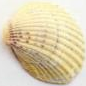

In [6]:
bbox = [
      494,
      227,
      580,
      313
    ]
fg_crop, mask_crop = get_foreground(
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/ground_truth.jpg',
    '/mnt/disk2/hachi/data/workdir/radish/hachi/OBJ_INS/phase2_V2/test/2_b1/mask_2.png',
    bbox
)
fg_crop

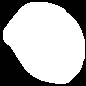

In [7]:
mask_crop